### Project 1 


We first import all the required packages. 

In [2]:
import numpy as np 
import pandas as pd 
from collections import Counter
import matplotlib.pyplot as plt

Problem 1a. 


##### One qubit study

Below you find functions for setting up the regular computational basis for one qubit, obtaining the Pauli gates. We also define the Hadamard and phase gates. We apply the different gates to the computational basis to see their effect. 



In [3]:
def one_qubit_basis():
    #One qubits basis states, computational basis 
    zero = np.array([1,0])
    one = np.array([0,1])
    return zero, one

def Pauli_gates():
    #Returns pauli gates 
    I = np.eye(2) #identity 
    Z = np.array([[1.0, 0.0], [0.0, -1.0]]) #Pauli Z
    X = np.array([[0.0, 1.0], [1.0, 0.0]]) #Pauli X
    Y = np.array([[0.0, -1.0j], [1.0j, 0.0]]) #Pauli Y 
    return I, Z, X, Y

#Function for applying gate to a state 
def apply_gate(gate, state):
    return gate @ state 



def apply_multiple_gates(gates, state0, state1):
    """
    Apply multiple gates to the given states to see their effect
    Arguments: - gates, assumed to be a dict with key being name of gate and value being the matrix representation of the gate in comp basis
               - state0, first state to apply gates to 
               - state1, second state to apply gates to
    Results are printed using pandas
    """

    data = [] #collect results of applying the gates to states. 
    for key, value in gates.items(): 
        #apply gate 
        result_zero = apply_gate(value, state0)
        result_one = apply_gate(value, state1)
        
        #append result to data
        data.append({"Gate": key, 
                    "Gate @ |0> = [1, 0]": format_state(result_zero),
                    "Gate @ |1> = [0, 1]": format_state(result_one)})


    #print a nice table using pandas 
    df = pd.DataFrame(data)

    # Improve display formatting
    pd.set_option("display.max_colwidth", None)

    print(df.to_string(index=False))


#Function for formatting when printing states
def format_state(state):
    return np.round(state, 3)


In [4]:
#Hadamard and Phase 
H = 1/np.sqrt(2) * np.array([[1, 1], [1, -1]]) #Hadamard 
S = np.array([[1, 0], [0, 1j]]) #Phase 
I, Z, X, Y = Pauli_gates()

#put all relevant gates in dict 
gates = {"I":I, "Z":Z, "X":X, "Y":Y, "H":H, "Phase gate":S}

zero, one = one_qubit_basis()

apply_multiple_gates(gates, zero, one)



      Gate Gate @ |0> = [1, 0] Gate @ |1> = [0, 1]
         I          [1.0, 0.0]          [0.0, 1.0]
         Z          [1.0, 0.0]         [0.0, -1.0]
         X          [0.0, 1.0]          [1.0, 0.0]
         Y            [0j, 1j]           [-1j, 0j]
         H      [0.707, 0.707]     [0.707, -0.707]
Phase gate        [(1+0j), 0j]            [0j, 1j]


##### Two-qubit study

We now move on to studying a system of two qubits. We define the Bell states, the CNOT gate, and functions that will simulate measurement on a given two-qubit state (in our case the Bell state $\ket{\Phi^+}$)

In [5]:
def Bell_states():
    #Returns the Bell states 
    Phi_plus = (1/np.sqrt(2)) * (np.kron(zero, zero) + np.kron(one, one)) 
    Phi_min = (1/np.sqrt(2)) * (np.kron(zero, zero) - np.kron(one, one))
    Psi_plus = (1/np.sqrt(2)) * (np.kron(zero, one) + np.kron(one, zero))
    Psi_min = (1/np.sqrt(2)) * (np.kron(zero, one) - np.kron(one, zero))
    return Phi_plus, Phi_min, Psi_plus, Psi_min

def CNOT_gate():
    #Returns CNOT gate (first qubit control, second qubit is target)
    P0 = np.outer(zero, zero) #|0><0|
    P1 = np.outer(one, one) # |1><1| 
    return np.kron(P0, I) + np.kron(P1, X)

def hadamard_on_two_qubits(qubit_index): 
    """
    The function returns the Hadamard applied to a single qubit in a two-qubit system 
    Argument: - qubit_index, specifies which qubit to apply Hadamard to
    """
    if qubit_index == 0: #apply Hadamard to first qubit
        H_I = np.kron(H, I)
        return H_I

    else:
        I_H = np.kron(I, H) #apply Hadamard to second qubit
        return I_H

def Hadamamard_and_CNOT(qubit_index, state): 
    """
    The function applies a Hadamard gate followed by a CNOT gate 
    - qubit_index: index for which qubit to apply Hadamard to
    - state: the quantum state that gates are applied to
    """
    Hadamard = hadamard_on_two_qubits(qubit_index)
    H_state = Hadamard @ state
    result = CNOT_gate() @ H_state
    return result


def sequential_measurement(state):
    """
    Sequential measurement in computational basis. First measure qubit 0 and then qubit 1. 
    Arguments: - state, state to be measured 
    """
    #probabilities for qubit0 
    probs0 = np.array([np.sum(np.abs(state[[0,1]])**2), np.sum(np.abs(state[[2,3]])**2)])
    outcome0 = np.random.choice([0,1], p=probs0)

    if outcome0 == 0:
        collapsed = state.copy()
        collapsed[2:] = 0  #amplitudes set to zero 
    else: 
        collapsed = state.copy()
        collapsed[0:2] = 0 

    #normalize 
    norm = np.linalg.norm(collapsed)
    collapsed = collapsed/norm

    #probabilities for qubit 1
    probs1 = np.array([np.sum(np.abs(collapsed[[0,2]])**2), np.sum(np.abs(collapsed[[1,3]])**2)])
    outcome1 = np.random.choice([0,1], p = probs1)

    return outcome0, outcome1 

        
#created with chatGPT for getting statistics and plotting them 
def simulate_measurements(state, n_shots=10000):
    """
    Measure both qubits sequentially n_shots times.
    Returns:
        - counts dictionary
        - empirical probabilities
        - mean and std per qubit
    """
    outcomes_q0 = []
    outcomes_q1 = []
    
    for _ in range(n_shots):
        o0, o1 = sequential_measurement(state)
        outcomes_q0.append(o0)
        outcomes_q1.append(o1)
    
    # Counts for each joint outcome
    joint_counts = Counter([f"{o0}{o1}" for o0,o1 in zip(outcomes_q0, outcomes_q1)])
    
    # Empirical probabilities
    joint_probs = {k: v/n_shots for k,v in joint_counts.items()}
    
    # Mean, standard deviation and standard error for each qubit
    mean_q0 = np.mean(outcomes_q0)
    std_q0  = np.std(outcomes_q0)
    se_q0 = std_q0/np.sqrt(n_shots)
    
    mean_q1 = np.mean(outcomes_q1)
    std_q1  = np.std(outcomes_q1)
    se_q1 = std_q1/np.sqrt(n_shots)


    
    return {
        "joint_counts": joint_counts,
        "joint_probs": joint_probs,
        "mean_q0": mean_q0,
        "std_q0": std_q0,
        "se_q0": se_q0,
        "mean_q1": mean_q1,
        "std_q1": std_q1,
        "se_q1": se_q1
    }


def simulations_multiple_shots(state, shots):
    """
    Function for simualting measurements with differing amounts of shots 
    Argument: - state, state to measure
              - shots, list of integers where each int corresponds to a given number of shots to use for a simulation
    """
    for shot in shots: 
        final_state = Hadamamard_and_CNOT(0, state)  # Apply H on qubit 0, CNOT with control 0
        results = simulate_measurements(final_state, n_shots=shot)
        print(f"Number of shots {shot}")
        print("\nJoint counts:")
        for k, v in results["joint_counts"].items():
            print(f"{k:>2} | {v:>6}")

        print("\nJoint probabilities:")
        for k, v in results["joint_probs"].items():
            print(f"{k:>2} | {v:>10.9f}")

        print("\nSummary:")
        print(f"{'Qubit':<8} | {'Mean':>12} | {'Std':>12} | {'SE':>6}")
        print("-" * 48)
        print(f"{0:<8} | {results['mean_q0']:>12.9f} | {results['std_q0']:>12.9f} | {results['se_q0']:>12.9f}")
        print(f"{1:<8} | {results['mean_q1']:>12.9f} | {results['std_q1']:>12.9f} | {results['se_q1']:>12.9f}")






We now apply a Hadamard gate to qubit 0, followed by the CNOT gate. We then proceed to measure the state, by first measuring qubit 0, followed by a measurement on qubit 1.

In [6]:
shots = [1000, 10000, 100000, 1000000] # number of shots for four simulations 
Phi_plus, _, _, _ = Bell_states()
simulations_multiple_shots(Phi_plus, shots) # perform simulations and print results to screen 


Number of shots 1000

Joint counts:
00 |    262
10 |    263
01 |    249
11 |    226

Joint probabilities:
00 | 0.262000000
10 | 0.263000000
01 | 0.249000000
11 | 0.226000000

Summary:
Qubit    |         Mean |          Std |     SE
------------------------------------------------
0        |  0.489000000 |  0.499878985 |  0.015807561
1        |  0.475000000 |  0.499374609 |  0.015791612
Number of shots 10000

Joint counts:
11 |   2492
00 |   2547
10 |   2470
01 |   2491

Joint probabilities:
11 | 0.249200000
00 | 0.254700000
10 | 0.247000000
01 | 0.249100000

Summary:
Qubit    |         Mean |          Std |     SE
------------------------------------------------
0        |  0.496200000 |  0.499985560 |  0.004999856
1        |  0.498300000 |  0.499997110 |  0.004999971
Number of shots 100000

Joint counts:
01 |  25062
11 |  25060
00 |  24849
10 |  25029

Joint probabilities:
01 | 0.250620000
11 | 0.250600000
00 | 0.248490000
10 | 0.250290000

Summary:
Qubit    |         Mean |          

#### Entropy and entanglement 

We now trace out one subsystem, and compute the Von Neumann entropy. 

In [7]:
#create density matrix: 
def create_density(state):
    return np.outer(state, np.conj(state))

#trace out second qubit 
def partial_trace(rho, dims, subsystem):
    """
    Compute partial trace over subsystem
    Arguments - rho, density matrix 
              - dims, tuple of dimensions of subsystem A and B 
              - subsystem, which subsystem to trace out, 0 traces out qubit 0, 1 traces out qubit 1

    Returns:  - returns reduced density matrix 
    """
    dA, dB = dims #dimensions of subsystem A and B 
    rho_reshaped = rho.reshape(dA, dB, dA, dB) #reshape rho 

    if subsystem == 0: 
        #Trace out A, keep B 
        rho_B = np.einsum('ikjk->ij', rho_reshaped) #sum over A axes 
        return rho_B
    elif subsystem == 1: 
        #trace out B, keep A
        rho_A = np.einsum('ijik->jk', rho_reshaped) #sum over B axes 
        return rho_A
    

def von_neumann_entropy(rho):
    """
    Computes von neumann entropy of density matrix 
    Argument: - rho, density matrix 
    """
    #obtain eigenvalues of density matrix 
    eigenvalues = np.linalg.eigvalsh(rho)
    eigenvalues = eigenvalues[eigenvalues > 1e-12] #avoid 0*log(0), when lambda_i = 0, no contribution to entropy. 
    S = -np.sum(eigenvalues * np.log2(eigenvalues))
    #compute von neumann entropy 
    return S



In [8]:
rho = create_density(Phi_plus)
dims = (2,2) #dimensions of subsystem A and B 
rho_B = partial_trace(rho, dims, 0)
rho_A = partial_trace(rho, dims, 1)
print("The Von Neumann entropy is:")
print(von_neumann_entropy(rho_A))


The Von Neumann entropy is:
1.0


#### Problem b

We know consider a Hamiltonian given by 
$$
    H(\lambda) = H_0 + \lambda H_1 
    = \mathcal{E} I + \Omega \sigma_z + \lambda (c I + \omega_z \sigma_z + \omega_x \sigma_x)
    = (\mathcal{E} + \lambda c )I + (\Omega + \lambda \omega_z) \sigma_z + \lambda \omega_x \sigma_x.
$$

We find its eigenvalues and study the behavior of its eigenstates. 

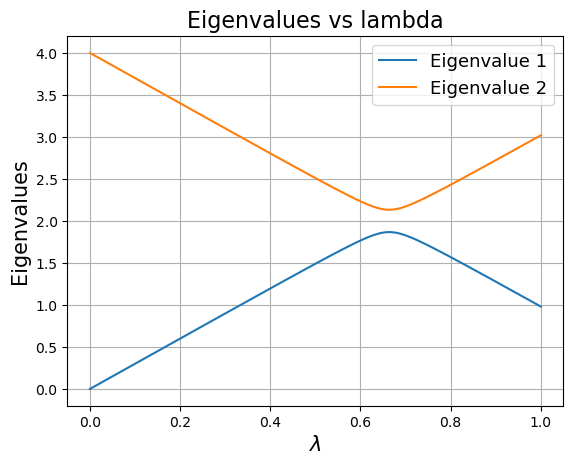

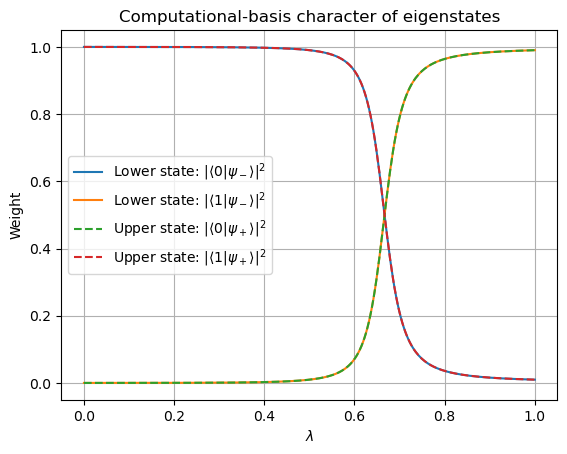

In [9]:
#Parameters 
E1 = 0
E2 = 4
V11 = 3
V22 = -V11
V12 = V21 = 0.2

#Construct hamiltonian
def hamiltonian(l=0.0):
    H_0 = np.array([[E1, 0], [0, E2]])
    H_i = np.array([[V11, V21], [V12, V22]])    
    return np.array(H_0 + l*H_i)


N = 300
lams = np.linspace(0, 1, N)

eigvals = np.zeros((N, 2))

# Store |0>- and |1>-weights for lower and upper eigenstates
lower_0 = []
lower_1 = []
upper_0 = []
upper_1 = []

for i, lam in enumerate(lams):
    w, v = np.linalg.eigh(hamiltonian(lam))

    #obtain and square coefficients to study behavior of eigenstates
    v_lower = v[:,0]
    v_upper = v[:,1]
    lower_0.append(abs(v_lower[0])**2)
    lower_1.append(abs(v_lower[1])**2)
    upper_0.append(abs(v_upper[0])**2)
    upper_1.append(abs(v_upper[1])**2)

    eigvals[i, :] = w

# Plot eigenvalues 
plt.plot(lams, eigvals[:, 0], label="Eigenvalue 1")
plt.plot(lams, eigvals[:, 1], label="Eigenvalue 2")

plt.xlabel(r"$\lambda$", fontsize=15)
plt.ylabel("Eigenvalues", fontsize=15)
plt.title("Eigenvalues vs lambda",fontsize=16)
plt.legend(fontsize=13)
plt.grid(True)
plt.show()

plt.plot(lams, lower_0, label=r"Lower state: $|\langle 0|\psi_-\rangle|^2$")
plt.plot(lams, lower_1, label=r"Lower state: $|\langle 1|\psi_-\rangle|^2$")
plt.plot(lams, upper_0, "--", label=r"Upper state: $|\langle 0|\psi_+\rangle|^2$")
plt.plot(lams, upper_1, "--", label=r"Upper state: $|\langle 1|\psi_+\rangle|^2$")

plt.xlabel(r"$\lambda$")
plt.ylabel("Weight")
plt.title("Computational-basis character of eigenstates")
plt.legend()
plt.grid()
plt.show()

#### Problem c

We will now implement the VQE algorithm for the Hamiltonian in problem b. 

In [10]:

#Parameters for Hamiltonian
c = (V11 + V22)/2
w_z = (V11 - V22)/2 
w_x = V12
eps = (E1+E2)/2
omega = (E1-E2)/2


H_0 = eps*I + omega*Z 
H_I = c*I + w_z*Z + w_x*X



#defining quantum rotation gates 
def Rx(theta): 
    "rotation about x-axis of angle theta"
    Rx = np.array([[np.cos(theta/2), -1j*np.sin(theta/2)],
                   [-1j*np.sin(theta/2), np.cos(theta/2)]], dtype=complex)
    return Rx

def Ry(theta): 
    "Rotation about y-axis of angle theta"
    Ry = np.array([[np.cos(theta/2), -np.sin(theta/2)], 
                   [np.sin(theta/2), np.cos(theta/2)]], dtype=complex)
    return Ry

def Rz(theta): 
    "Rotation about z-axis of angle theta"
    Rz = np.array([[np.exp(-1j*theta/2), 0], [0, np.exp(1j*theta/2)]], dtype=complex)

    return Rz

def ansatz_state(angles): 
    """
    Ansatz state 
    Arguments: - angles, parameters assumed to be array of 3 angles or 1 angle
    """
    if len(angles) == 1: 
        U = Ry(angles[0])
    else:
        U = Rz(angles[2])@Ry(angles[1])@Rz(angles[0]) #standard ansatz U = RzRyRz, I shall try with RxRyRx as well 
    state = U @ np.array([1,0])
    return state


def measure_Z(state, shots): 
    """
    Measures state in Z basis 
    Arguments: - State, state to be measured, np.array
               - shots, number of shots (measurements)
    """
    
    #probabilities 
    probs = np.abs(state)**2
   

    #Do measurements and count the number of times we measure 0 and 1
    n0 = np.random.binomial(shots, probs[0])
    n1 = shots - n0

    mean = (n0 - n1)/shots
    counts = (n0, n1)

    return mean, counts


def measure_X(state, shots): 
    """
    Rotate X to Z with Hadamard to measure in X 
    Arguments: - state, state to be measured 
               - shots, number of measurements/shots 
    """

    #rotate state 
    rotated_state = H @ state 

    #perform measurment in Z basis after rotation 
    mean, counts = measure_Z(rotated_state, shots)

    return mean, counts 

def measure_Y(state, shots): 
    """
    Rotate Y to Z with Hadamard gate and dagger of phase gate to measure in Y
    Arguments: - state, state to be measured 
               - shots, number of measurements/shots 
    """

    #rotate state with phase gate and hadamard gate 
    rotated_state = H @ (S.conj().T @ state) 

    #perform measurement in Z basis after rotation 

    mean, counts = measure_Z(rotated_state, shots)

    return mean, counts 



def measure_energy(state, shots, coeffs): 
    """
    Measure energy of the Hamiltonian when it is written as sum of Pauli gates
    Arguments: - state, state to be measured 
               - shots, number of shots 
               - coeffs, dictionary containing the coefficients infront the Pauli-terms in Hamiltonian
    """

    #measure I 
    E_I = coeffs["I"] 

    #measure Z 
    measure_z, _ = measure_Z(state, shots)
    E_Z = coeffs["Z"] * measure_z

    #Measure X 
    measure_x, _ = measure_X(state, shots)
    E_X = coeffs["X"] * measure_x

    E = E_I + E_Z + E_X

    return E 


def energy_one_qubit(params, shots, coeffs):
    """
    Calculates expectation of energy for a one qubit system 
    Arguments: - params, parameters used in ansatz state 
               - shots, number of shots 
               - coeffs, dict type, coeffcients infront of Pauli matrices making up the Hamiltonian
    """
    state = ansatz_state(params)
    return measure_energy(state, shots, coeffs)


class AdamOptimizerVQE: 
    """
    Minimal gradient descent used in VQE 
    """
    def __init__(self, energy_fn):
        """ 
        Arguments - energy, function that measures energy. taken as argument as class will be used for both 1 qubit and 2 qubit case 
        """
        self.energy = energy_fn

    #compute energy
    def energy(self, params): 
        state = ansatz_state(params)
        return measure_energy(state, self.shots, self.coeffs)
    
    #compute gradient using parameter-shift rule 
    def gradient(self, params, shift = np.pi/2):
        params = np.asarray(params, dtype=float)
        grads = np.zeros_like(params)
        for i in range(len(params)):
            p_plus = params.copy()
            p_min = params.copy()
            p_plus[i] += shift 
            p_min[i] -= shift 

            e_plus = self.energy(p_plus)
            e_min = self.energy(p_min)
            grads[i] = (e_plus-e_min)/2
        return grads
    
    #Optimization part, Adam Optimizer 
    def optimize_Adam(self, params, lr=0.1, beta_1 = 0.9, beta_2 = 0.99, eps = 1e-9, maxiter = 500):
        angles = np.asarray(params, dtype=float).copy()
        m = np.zeros_like(angles)
        v = np.zeros_like(angles)
        history = []
        for i in range(1, maxiter + 1):
            g = self.gradient(angles)
            m = beta_1 * m + (1 - beta_1) * g
            v = beta_2 * v + (1 - beta_2) * (g * g)
            m_hat = m/(1-beta_1**i)
            v_hat = v/(1-beta_2**i)
            angles = angles - lr * m_hat/(np.sqrt(v_hat) + eps)
            history.append(self.energy(angles))

        return {"angles":angles, "energy":history[-1]}

    


    


def find_lowest_eigenvalues_VQE(params, shots, lmbda):
    """
    Finds lowest energy using VQE method 
    Arguments: - params, parameters used in VQE ansatz, assumed to be array of 3 angles or 1 angle
               - shots, number of shots 
               - lmbda, array of lambda values 
    """

    
    energies = []
    for lam in lmbda:
        #coefficients infront of Pauli matrices, for H_0 and H_1 
        coeffs = {"I": eps+c*lam, "Z": omega + w_z*lam, "X":w_x*lam}
        vqe = AdamOptimizerVQE(lambda p: energy_one_qubit(p, shots, coeffs))
        values = vqe.optimize_Adam(params)

        energies.append(values["energy"])

    return energies




        





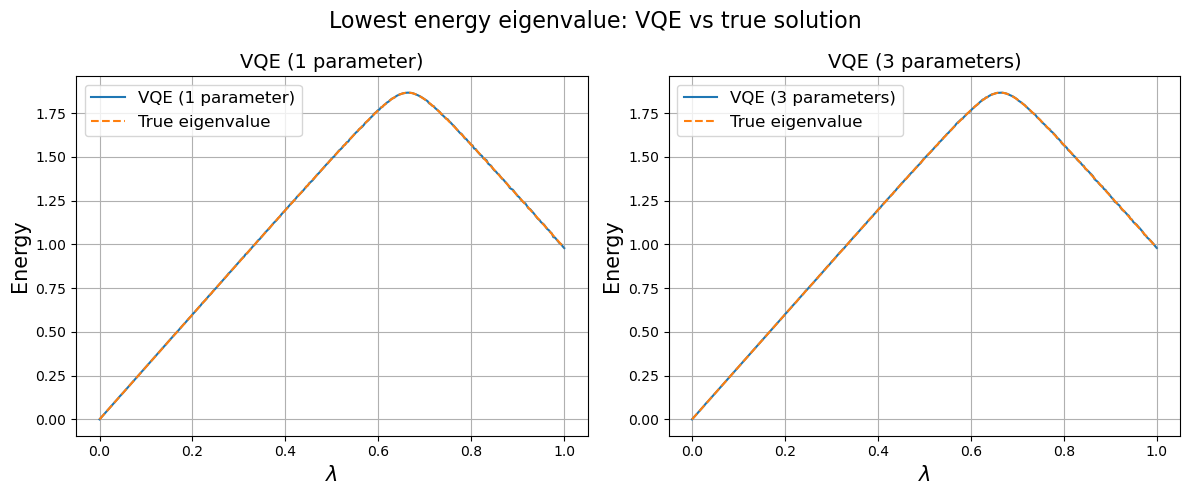

In [11]:
lmbda = np.linspace(0,1,300)
shots = 10000
params_3 = np.random.uniform(0, 2*np.pi, 3) # Ansatz with three parameters 
params_1 = np.random.uniform(0, 2*np.pi, 1) # Ansatz with only one parameter 

energies_vqe_3 = find_lowest_eigenvalues_VQE(params_3, shots, lmbda)
energies_vqe_1 = find_lowest_eigenvalues_VQE(params_1, shots, lmbda)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))  

# First plot 1 parameter
axes[0].plot(lmbda, energies_vqe_1, "-", label="VQE (1 parameter)")
axes[0].plot(lmbda, eigvals[:,0], "--", label="True eigenvalue")
axes[0].set_xlabel(r"$\lambda$", fontsize=15)
axes[0].set_ylabel("Energy", fontsize=15)
axes[0].set_title("VQE (1 parameter)", fontsize=14)
axes[0].legend(fontsize=12)
axes[0].grid(True)

# Second plot 3 parameters
axes[1].plot(lmbda, energies_vqe_3, "-", label="VQE (3 parameters)")
axes[1].plot(lmbda, eigvals[:,0], "--", label="True eigenvalue")
axes[1].set_xlabel(r"$\lambda$", fontsize=15)
axes[1].set_ylabel("Energy", fontsize=15)
axes[1].set_title("VQE (3 parameters)", fontsize=14)
axes[1].legend(fontsize=12)
axes[1].grid(True)

fig.suptitle("Lowest energy eigenvalue: VQE vs true solution", fontsize=16)

plt.tight_layout()
fig.savefig("vqe_comparison.pdf", bbox_inches="tight")
plt.show()






#### Qiskit comparison
We also compare our VQE method to the solution obtained using Qiski. 

In [12]:
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit_algorithms import VQE
from qiskit.primitives import StatevectorEstimator as Estimator
from qiskit_algorithms.optimizers import ADAM

In [13]:
def qiskit_vqe(params, lmbda):
    """
    Method for doing VQE with Qiskit 
    Arguments - params, parameters for VQE 
              - lmbda, array of lambda values
    """
    

    params_vec = ParameterVector("theta", 3)
    qc = QuantumCircuit(1)
    qc.rz(params_vec[0], 0)
    qc.ry(params_vec[1], 0)
    qc.rz(params_vec[2], 0)

    estimator = Estimator()
    qiskit_optimizer = ADAM(maxiter=500, lr=0.1)
    qiskit_energies = []
    

    
    for count, lam in enumerate(lmbda):
            
  
        coeffs = {"I": eps + c*lam, "Z": omega + w_z*lam, "X": w_x*lam}
        
        
        H = SparsePauliOp.from_list([
            ("I", coeffs["I"]), 
            ("Z", coeffs["Z"]), 
            ("X", coeffs["X"])
        ])
        
        vqe_q = VQE(estimator, qc, qiskit_optimizer, initial_point=params)
        res_q = vqe_q.compute_minimum_eigenvalue(H)
        qiskit_energies.append(res_q.eigenvalue.real)

    return qiskit_energies


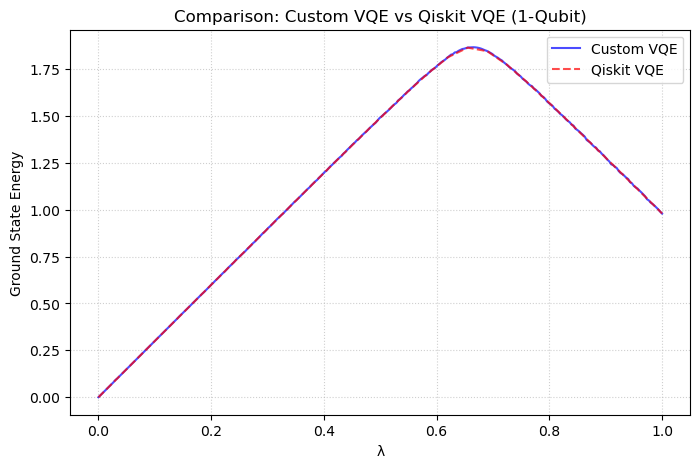

In [14]:
#obtain qiskit energies and plot 
qiskit_energies = qiskit_vqe(params_3, np.linspace(0,1,30)) #fewer points for qiskit as qiskit is slow
plt.figure(figsize=(8, 5))
plt.plot(lmbda, energies_vqe_3, 'b-', label="Custom VQE", alpha=0.7)
plt.plot(np.linspace(0,1,30), qiskit_energies, 'r--', label="Qiskit VQE", alpha=0.7)

plt.xlabel("λ")
plt.ylabel("Ground State Energy")
plt.title("Comparison: Custom VQE vs Qiskit VQE (1-Qubit)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig("vqe_comparison_e3.pdf", bbox_inches="tight")


##### Problem d

We now turn to a two-qubit system. The Hamiltonian is given by $H = H_0 + H_I$, where $H_I = H_x X \otimes X  + H_zZ\otimes Z$, for parameters $H_x$ and $H_z$. $H_0 = \mathrm{diag}(\epsilon_{00}, \epsilon_{11}, \epsilon_{22}, \epsilon_{33})$ where the $\epsilon_{ij}$ are parameters. 

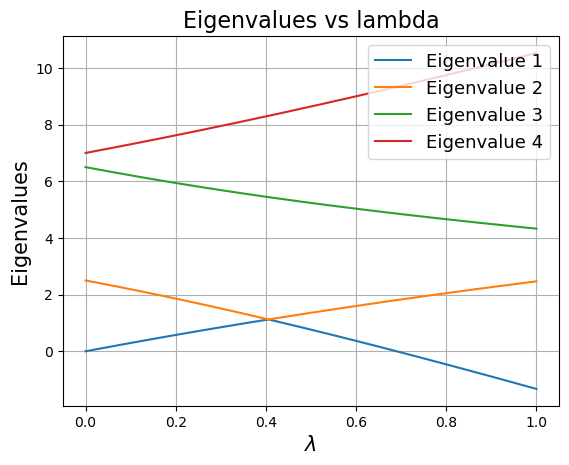

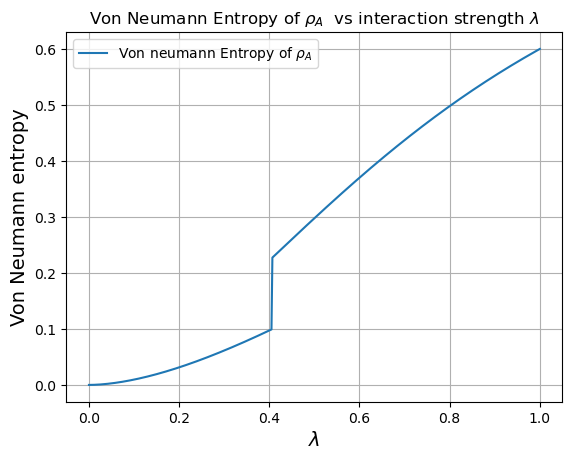

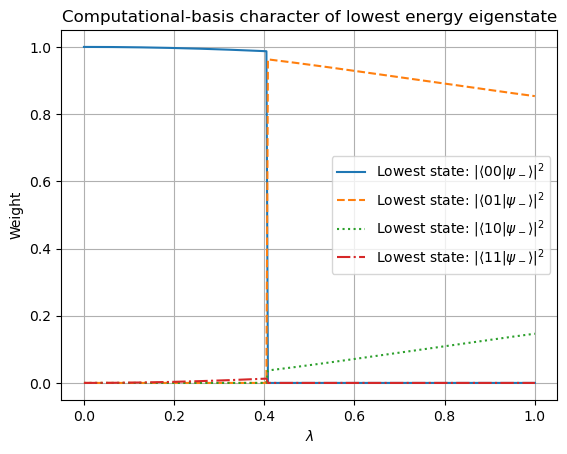

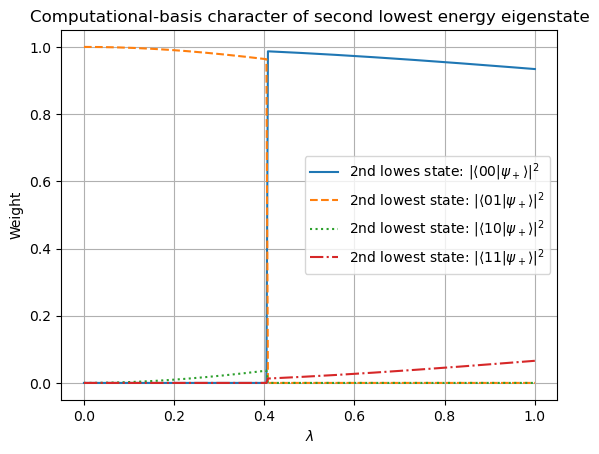

In [15]:
#define two-qubit Pauli gates 
II = np.kron(I, I)
IZ = np.kron(I, Z)
ZI = np.kron(Z, I)
ZZ = np.kron(Z, Z)
XX = np.kron(X, X)


#parameters 
eps_00 = 0.0 
eps_11 = 2.5
eps_22 = 6.5 
eps_33 = 7.0
Hx = 2.0
Hz = 3.0


def construct_Hamiltonian(eps_00, eps_11, eps_22, eps_33, Hx, Hz, lam):
    """
    Construct Hamiltonian
    Argument: lam, interaction strength parameter
    """
    #Write Hamiltonian as sum of Pauli operators, coefficients are defined 
    alpha = (1/4)*(eps_00+eps_11+eps_22+eps_33)
    beta = (1/4)*(eps_00+eps_11-eps_22-eps_33)
    gamma = (1/4)*(eps_00-eps_11+eps_22-eps_33)
    delta = (1/4)*(eps_00-eps_11-eps_22+eps_33)
    #Hamiltonian, H0, HI and total
    H_0 = alpha*II + beta*ZI + gamma*IZ + delta*ZZ
    H_I = Hx * XX + Hz * ZZ
    #Full Hamiltonian
    Hamiltonian = H_0 + lam*H_I
    #print(Hamiltonian)
    coeffs = {"I":alpha, "ZI":beta, "IZ":gamma, "ZZ":delta+lam*Hz, "XX":lam*Hx}
    return Hamiltonian, coeffs 




def construct_comp_basis():
    zero_zero = np.array([1,0,0,0])
    zero_one = np.array([0,1,0,0])
    one_zero = np.array([0,0,1,0])
    one_one = np.array([0,0,0,1])
    return zero_zero, zero_one, one_zero, one_one



def compute_eigvals(N):
    """
    Computes the eigenvalues for different values of parameter strength lmbda 
    
    Arguments: - N, number of different lmbda values to compute eigenvalues for
    """
    lmbda = np.linspace(0,1,N)
    eigvals = np.zeros((N,4)) #empty to hold eigvals later 

    #store amplitudes of eigenvalues to study mixing 
    lower_00 = []
    lower_01 = []
    lower_10 = []
    lower_11 = []
    upper_00 = []
    upper_01 = []
    upper_10 = []
    upper_11 = []

    for i, lam in enumerate(lmbda): 
        H, _ = construct_Hamiltonian(eps_00, eps_11, eps_22, eps_33, Hx, Hz, lam)
        eigvals_lam, eigvecs_lam = np.linalg.eigh(H)

        #only get the two lowest eigenvecs as these are the ones of relevance for our analysis 
        v_0 = eigvecs_lam[:, 0]
        v_1 = eigvecs_lam[:, 1]

        lower_00.append(abs(v_0[0])**2)
        lower_01.append(abs(v_0[1])**2)
        lower_10.append(abs(v_0[2])**2)
        lower_11.append(abs(v_0[3])**2)
        upper_00.append(abs(v_1[0])**2)
        upper_01.append(abs(v_1[1])**2)
        upper_10.append(abs(v_1[2])**2)
        upper_11.append(abs(v_1[3])**2)
        amplitudes = [lower_00, lower_01, lower_10, lower_11, upper_00, upper_01, upper_10, upper_11]
        eigvals[i,:] = eigvals_lam

    return lmbda, eigvals, amplitudes


def compute_entanglement(N, dims, subsystem):
    """
    Computes entanglement for two-qubit system as function of interaction strength lambda

    Arguments: - dims, dimensions of subsystems, tuple
               - subsystem, which subsystem to trace out 
    """
    lmbda = np.linspace(0,1,N)
    entropies = np.zeros_like(lmbda)
    for i,lam in enumerate(lmbda): 
        #construct Hamiltonian and obtain eigenstates 
        H, _= construct_Hamiltonian(eps_00, eps_11, eps_22, eps_33, Hx, Hz, lam)
        _, eigvecs = np.linalg.eigh(H)
        #get lowest energy state and compute its density matrix
        lowest_state = eigvecs[:,0] 
        rho = create_density(lowest_state)
        #Take partial trace of qubit 1
        reduced_rho = partial_trace(rho, dims, subsystem = subsystem)
        #Compute Von Neumann entropy 
        entropy = von_neumann_entropy(reduced_rho)
        entropies[i] = entropy
    return lmbda, entropies 



def plot_entropy_vs_lmbda(subsystem):

    """
    Plots Von Neumann entropy as a function of lambda 
    Arguments: - subsystem, which subsystem to trace out
    """
    lmbda, entropies = compute_entanglement(N=500, dims=(2,2), subsystem = subsystem)
  

    plt.plot(lmbda, entropies, label = r"Von neumann Entropy of $\rho_A$")
    plt.xlabel(r"$\lambda$", fontsize = 14)
    plt.ylabel("Von Neumann entropy", fontsize = 14)
    plt.title(r"Von Neumann Entropy of $\rho_A$  vs interaction strength $\lambda$")
    plt.legend()
    plt.grid(True)
    plt.savefig("entropy_vs_lmbda.pdf", bbox_inches="tight")
    plt.show()



def plot_lmbda_vs_two_lowest_eigvecs(lmbda, eigvecs):
    plt.plot(lmbda, eigvecs[0], label=r"Lowest state: $|\langle 00|\psi_-\rangle|^2$")
    plt.plot(lmbda, eigvecs[1], "--", label=r"Lowest state: $|\langle 01|\psi_-\rangle|^2$")
    plt.plot(lmbda, eigvecs[2], ":" ,label=r"Lowest state: $|\langle 10|\psi_-\rangle|^2$")
    plt.plot(lmbda, eigvecs[3], "-.",label=r"Lowest state: $|\langle 11|\psi_-\rangle|^2$")
    plt.xlabel(r"$\lambda$")
    plt.ylabel("Weight")
    plt.title("Computational-basis character of lowest energy eigenstate")
    plt.legend()
    plt.grid()
    plt.savefig("lowest_eig_state.pdf", bbox_inches="tight")
    plt.show()
    plt.plot(lmbda, eigvecs[4], label=r"2nd lowes state: $|\langle 00|\psi_+\rangle|^2$")
    plt.plot(lmbda, eigvecs[5], "--", label=r"2nd lowest state: $|\langle 01|\psi_+\rangle|^2$")
    plt.plot(lmbda, eigvecs[6], ":", label=r"2nd lowest state: $|\langle 10|\psi_+\rangle|^2$")
    plt.plot(lmbda, eigvecs[7], "-.", label=r"2nd lowest state: $|\langle 11|\psi_+\rangle|^2$")
    plt.xlabel(r"$\lambda$")
    plt.ylabel("Weight")
    plt.title("Computational-basis character of second lowest energy eigenstate")
    plt.legend()
    plt.grid()
    plt.savefig("2nd_lowest_eigstate.pdf", bbox_inches="tight")
    plt.show()

   

def plot_lmbda_vs_eigvals(lmbda, eigvals):

    plt.plot(lmbda, eigvals[:, 0], label="Eigenvalue 1")
    plt.plot(lmbda, eigvals[:, 1], label="Eigenvalue 2")
    plt.plot(lmbda, eigvals[:, 2], label="Eigenvalue 3")
    plt.plot(lmbda, eigvals[:, 3], label="Eigenvalue 4")

    plt.xlabel(r"$\lambda$", fontsize=15)
    plt.ylabel("Eigenvalues", fontsize=15)
    plt.title("Eigenvalues vs lambda",fontsize=16)
    plt.legend(fontsize=13)
    plt.grid(True)
    plt.savefig("lmbda_vs_eigvals_4.pdf", bbox_inches="tight")
    plt.show()

lmbda, eigvals, eigvecs = compute_eigvals(N=300)
plot_lmbda_vs_eigvals(lmbda, eigvals)
plot_entropy_vs_lmbda(subsystem = 0)
plot_lmbda_vs_two_lowest_eigvecs(lmbda, eigvecs)


#### Problem e


We now compute the lowest eigenvalue by extending our VQE code to a two-qubit.

In [16]:

state_00 = np.array([1,0,0,0])
CNOT = CNOT_gate()
H_H =  np.kron(H, H) #hadamrd gates for rotating to Z when measuring X 

def ansatsz_two_qubits(params):
    """
    Prepares ansatz two-qubit state for VQE algorithm
    
    Arguments - params: parameters used for the rotation gates in the ansatz 
    """
    #First layer of rotations in circuit, trying with RxRz first, might try something different later 
    U1_0 = Rx(params[0]) @ Rz(params[1])
    U1_1 = Rx(params[2]) @ Rz(params[3])
    U1 = np.kron(U1_0, U1_1)

    #Second layer (after CNOT)
    U2_0 = Rz(params[4]) @ Rx(params[5])
    U2_1 = Rz(params[6]) @ Rx(params[7])
    U2 = np.kron(U2_0, U2_1)

    #squeeze CNOT between layers, first qubit is control 
    U = U2 @ CNOT @ U1

    #return U applied to |00> 
    return U @ state_00



def measurement_two_qubits(state, shots): 
    """
    Perform measurement on the two qubits simultaneously in computational basis
    Counts the number of times each outcome occurs 
    
    Arguments: - state, state to be measured
               - shots, number of shots 
    """
    
    #probabilities 
    probs = np.abs(state)**2

    measurements = np.random.multinomial(shots, probs)

    
    counts = {"00":measurements[0], "01":measurements[1], "10":measurements[2], "11":measurements[3]}
    return counts 
    
   
def measure_ZZ(state, shots):
    """
    Measure ZZ in comp basis 
    Arguments: - state, state to be measured 
               - shots, number of shots 
    """
    counts = measurement_two_qubits(state, shots)
    mean = (counts["00"] + counts["11"] - counts["01"] - counts["10"])/shots

    return mean, counts

def measure_IZ(state, shots):
    """
    Measure IZ in comp basis 
    Arguments: - state, state to be measured 
               - shots, number of shots 
    """
    counts = measurement_two_qubits(state, shots)
    mean = (counts["00"] + counts["10"] - counts["01"] - counts["11"])/shots

    return mean, counts 

def measure_ZI(state, shots):
    """
    Measure ZI in comp basis 
    Arguments: - state, state to be measured 
               - shots, number of shots 
    """
    counts = measurement_two_qubits(state, shots)
    mean = (counts["00"] + counts["01"] - counts["10"] - counts["11"])/shots

    return mean, counts 

def measure_XX(state, shots):
    """
    Measure XX in comp basis, rotate to XX to ZZ then measure 
    Arguments: - state, state to be measured 
               - shots, number of shots 
    """

    rotated_state = H_H @ state
    mean, counts = measure_ZZ(rotated_state, shots)
   
    return mean, counts 

def measure_energy_two_qubits(state, shots, coeffs):
    """
    Measures total energy 
    Arguments: - state, state to be measured 
               - shots, number of shots 
               - coeffs, coefficients infront of Pauli terms of Hamiltonian 
    """
    #II term 
    E_II = coeffs["I"]

    #IZ term
    e_iz, _ = measure_IZ(state, shots)
    E_IZ = coeffs["IZ"] * e_iz

    #ZI term 
    e_zi, _ = measure_ZI(state, shots)
    E_ZI = coeffs["ZI"] * e_zi

    #ZZ term 
    e_zz, _ = measure_ZZ(state, shots)
    E_ZZ  = coeffs["ZZ"] * e_zz

    #XX term 
    e_xx, _ = measure_XX(state, shots)
    E_XX = coeffs["XX"] * e_xx

    #total energy
    E_tot = E_II + E_IZ + E_ZI + E_ZZ + E_XX

    return E_tot


def energy_two_qubits(params, shots, coeffs):
    """
    Expectation value of energy for two qubit system 
    Arguments: - parmas, paraeterss used in ansatz state 
               - shots, number of shots 
               - coeffs, dict type, coefficient for the Pauli matrices making up the Hamiltonian 
    """
    state = ansatsz_two_qubits(params)
    return measure_energy_two_qubits(state, shots, coeffs)

def find_lowest_eigenvalues_VQE_two_qubits(lmbda, shots, params):
    """
    Find and plot lowest eigenvalue as function of lambda
    Arguments - lmbda, lmbda values
              - shots, number of shots 
              - params, parameters used in ansatz state 
    """
    energies = []
    for lam in lmbda:
        #coefficients infront of Pauli matrices, for H_0 and H_1 
        _, coeffs = construct_Hamiltonian(eps_00, eps_11, eps_22, eps_33, Hx, Hz, lam)
        vqe = AdamOptimizerVQE(lambda p: energy_two_qubits(p, shots, coeffs))
        values = vqe.optimize_Adam(params)
        energies.append(values["energy"])
     
    return energies


In [17]:
lmbda = np.linspace(0,1, 300)
params = np.random.uniform(0, 2*np.pi, 8)
shots = 10000

energies = find_lowest_eigenvalues_VQE_two_qubits(lmbda, shots, params)


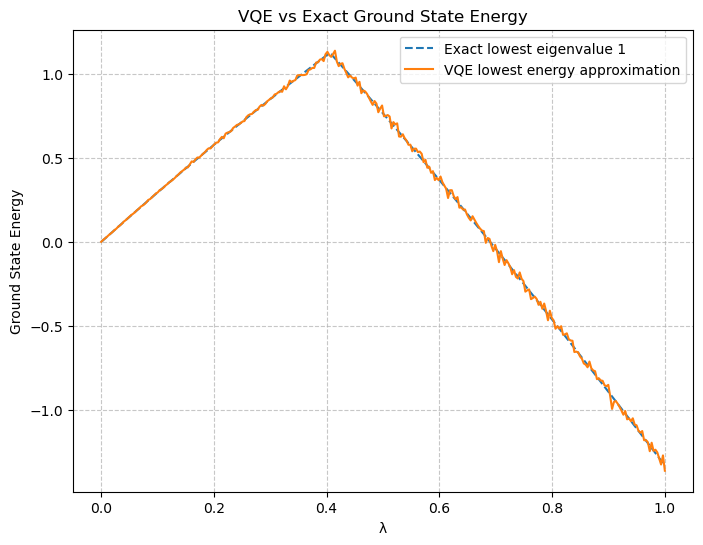

In [18]:
plt.figure(figsize=(8, 6))

# Plot exact solution as a continuous line
plt.plot(lmbda, eigvals[:, 0], "--", label="Exact lowest eigenvalue 1")

# Plot VQE solution as scatter points
plt.plot(lmbda, energies, label="VQE lowest energy approximation", zorder=2)

plt.title("VQE vs Exact Ground State Energy")
plt.xlabel("λ")
plt.ylabel("Ground State Energy")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("VQE_exact.pdf", bbox_inches="tight")
plt.show()

#### Qiskit comparison

We now compare with Qiskit as well 

In [19]:
def qiskit_vqe_two_qubit(params, lmbda):
    """
    VQE with Qiskit 
    """
    # Qiskit Circuit Setup
    params_vec = ParameterVector("theta", 8)
    qc = QuantumCircuit(2)
    qc.rx(params_vec[0], 0)
    qc.rz(params_vec[1], 0)
    qc.rx(params_vec[2], 1)
    qc.rz(params_vec[3], 1)
    qc.cx(0, 1)
    qc.rz(params_vec[4], 0)
    qc.rx(params_vec[5], 0)
    qc.rz(params_vec[6], 1)
    qc.rx(params_vec[7], 1)

    estimator = Estimator()
    qiskit_optimizer = ADAM(maxiter=500, lr=0.1)

    qiskit_energies = []
    
    
    for count, lam in enumerate(lmbda):
        

        _, coeffs = construct_Hamiltonian(eps_00, eps_11, eps_22, eps_33, Hx, Hz, lam)

        H = SparsePauliOp.from_list([
            ("II", coeffs.get("I", 0.0)),
            ("ZI", coeffs.get("IZ", 0.0)), # Qiskit ZI = Z on q1, I on q0
            ("IZ", coeffs.get("ZI", 0.0)), # Qiskit IZ = I on q1, Z on q0
            ("ZZ", coeffs.get("ZZ", 0.0)),
            ("XX", coeffs.get("XX", 0.0)),
            ("YY", coeffs.get("YY", 0.0)),
            ("IX", coeffs.get("IX", 0.0)),
            ("ZX", coeffs.get("ZX", 0.0))
        ])

        vqe_qiskit = VQE(estimator, qc, qiskit_optimizer, initial_point=params)
        result = vqe_qiskit.compute_minimum_eigenvalue(H)
        qiskit_energies.append(result.eigenvalue.real)

    return qiskit_energies



In [20]:

params = np.random.uniform(0, 2*np.pi, 8)


energies_qiskit = qiskit_vqe_two_qubit(params, np.linspace(0,1,30)) #fewer points for qiskit as qiskit is slow


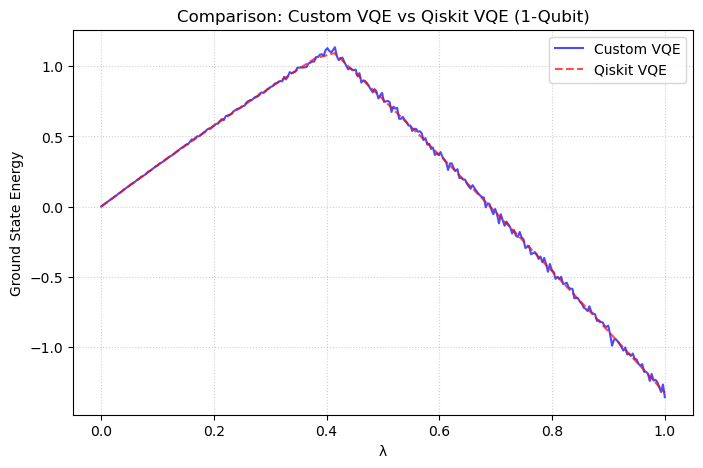

In [21]:
lmbda_energies = np.linspace(0,1, 300) #need same lmbda as for our VQE solution. 

plt.figure(figsize=(8, 5))
plt.plot(lmbda_energies, energies, 'b-', label="Custom VQE", alpha=0.7)
plt.plot(np.linspace(0,1,30), energies_qiskit, 'r--', label="Qiskit VQE", alpha=0.7)

plt.xlabel("λ")
plt.ylabel("Ground State Energy")
plt.title("Comparison: Custom VQE vs Qiskit VQE (1-Qubit)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig("vqe_comparison_e.pdf", bbox_inches="tight")

#### Problem f 

We will now move on to studying the Lipkin Model. We diagonalize the Hamiltonian for a $3 \times 3$ case, as well as for a $5 \times 5$ case. 

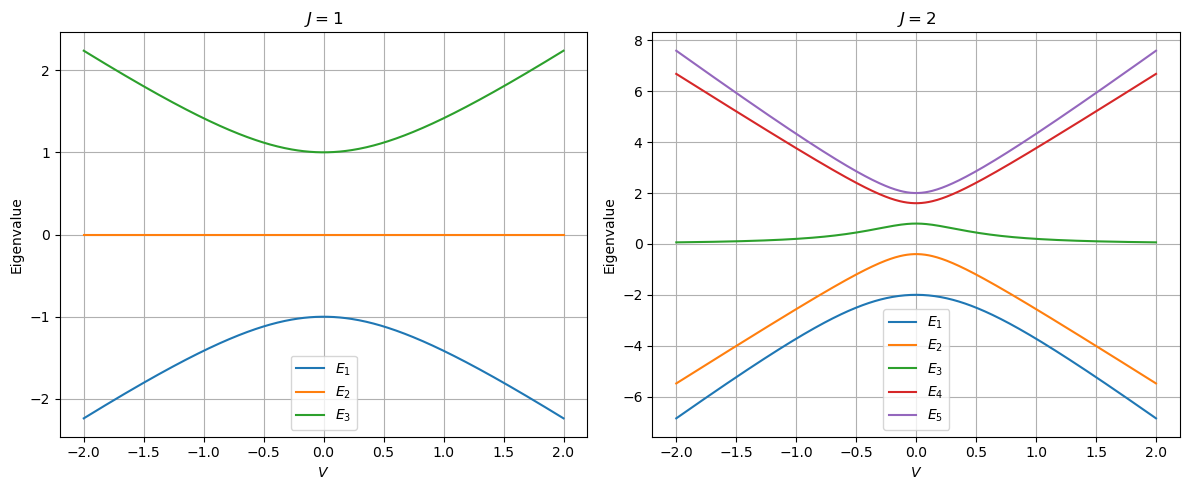

In [22]:
eps = 1.0
W = 0.2

#Interaction strength
V_vals = np.linspace(-2.0, 2.0, 400)

eigvals_J1 = []
eigvals_J2 = []

for V in V_vals:
    #J = 1 Hamiltonian
    H_J1 = np.array([
        [-eps, 0.0, -V],
        [0.0,  0.0,  0.0],
        [-V,  0.0,  eps]
    ], dtype=float)

    #J = 2 Hamiltonian
    H_J2 = np.array([
        [-2*eps,      0.0,         np.sqrt(6)*V, 0.0,         0.0],
        [0.0,         -eps + 3*W,  0.0,         3*V,         0.0],
        [np.sqrt(6)*V, 0.0,        4*W,         0.0,         np.sqrt(6)*V],
        [0.0,          3*V,        0.0,         eps + 3*W,   0.0],
        [0.0,          0.0,        np.sqrt(6)*V, 0.0,        2*eps]
    ], dtype=float)

  
    eigvals_J1.append(np.linalg.eigvalsh(H_J1))
    eigvals_J2.append(np.linalg.eigvalsh(H_J2))

eigvals_J1 = np.array(eigvals_J1)
eigvals_J2 = np.array(eigvals_J2)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))


for i in range(eigvals_J1.shape[1]):
    axes[0].plot(V_vals, eigvals_J1[:, i], label=fr"$E_{i+1}$")
axes[0].set_title(r"$J=1$")
axes[0].set_xlabel(r"$V$")
axes[0].set_ylabel("Eigenvalue")
axes[0].grid(True)
axes[0].legend()


for i in range(eigvals_J2.shape[1]):
    axes[1].plot(V_vals, eigvals_J2[:, i], label=fr"$E_{i+1}$")
axes[1].set_title(r"$J=2$")
axes[1].set_xlabel(r"$V$")
axes[1].set_ylabel("Eigenvalue")
axes[1].grid(True)
axes[1].legend()
plt.savefig("f_energies.pdf", bbox_inches="tight")
plt.tight_layout()
plt.show()





#### Problem g

We need to update our function for the energy as our relevant matrix now contains more pauli terms. 

In [23]:
def measure_YY(state, shots):
    """
    Measure YY in comp basis, rotate YY to ZZ then measure
    Arguments: - state, state to be measured
               - shots, number of shots
    """
    # The unitary matrix to rotate the Y basis to the Z basis (H @ S_dagger)
    U_y = np.array([[1, -1j], 
                    [1,  1j]]) / np.sqrt(2)
    
    
    rot_YY = np.kron(U_y, U_y) #rotate
    rotated_state = rot_YY @ state
    mean, counts = measure_ZZ(rotated_state, shots)


    
    return mean, counts

def measure_IX(state, shots):
    # Apply Hadamard to the second qubit to rotate to X basis
    H_mat = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
    rot = np.kron(np.eye(2), H_mat) 
    return measure_IZ(rot @ state, shots)

def measure_ZX(state, shots):
    # Apply Hadamard to the second qubit
    H_mat = np.array([[1, 1], [1, -1]]) / np.sqrt(2)
    rot = np.kron(np.eye(2), H_mat) 
    return measure_ZZ(rot @ state, shots)

def measure_energy_Lipkin(state, shots, coeffs):
    """
    Measures total energy 
    Arguments: - state, state to be measured 
               - shots, number of shots 
               - coeffs, coefficients infront of Pauli terms of Hamiltonian 
    """    
    E_II = coeffs.get("I", 0.0)

    e_iz, _ = measure_IZ(state, shots)
    E_IZ = coeffs.get("IZ", 0.0) * e_iz

    e_zi, _ = measure_ZI(state, shots)
    E_ZI = coeffs.get("ZI", 0.0) * e_zi

    e_zz, _ = measure_ZZ(state, shots)
    E_ZZ  = coeffs.get("ZZ", 0.0) * e_zz

    e_xx, _ = measure_XX(state, shots)
    E_XX = coeffs.get("XX", 0.0) * e_xx

    e_yy, _ = measure_YY(state, shots)
    E_YY = coeffs.get("YY", 0.0) * e_yy

    e_ix, _ = measure_IX(state, shots)
    E_IX = coeffs.get("IX", 0.0) * e_ix

    e_zx, _ = measure_ZX(state, shots)
    E_ZX = coeffs.get("ZX", 0.0) * e_zx

    # Total energy
    E_tot = E_II + E_IZ + E_ZI + E_ZZ + E_XX + E_YY + E_IX + E_ZX

    return E_tot

def energy_two_qubits_Lipkin(params, shots, coeffs):
    """
    Expectation value of energy for two qubit system 
    Arguments: - parmas, paraeterss used in ansatz state 
               - shots, number of shots 
               - coeffs, dict type, coefficient for the Pauli matrices making up the Hamiltonian 
    """
    state = ansatsz_two_qubits(params)
    return measure_energy_Lipkin(state, shots, coeffs)
    


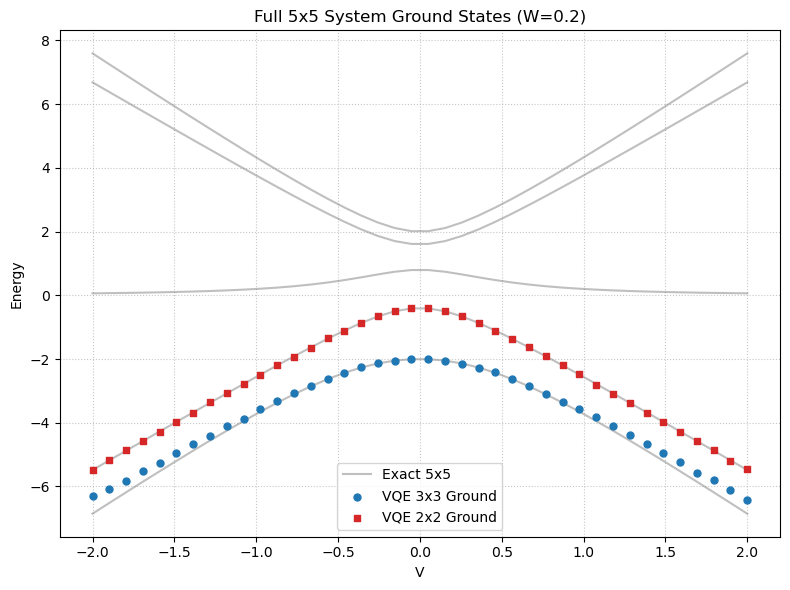

In [24]:

eps = 1.0
W = 0.2
V_vals = np.linspace(-2.0, 2.0, 40)  
shots = 20000

exact_energies = []
vqe_2x2_ground = []
vqe_3x3_ground = []

for V in V_vals:
    H_5x5 = np.array([
        [-2*eps, 0, np.sqrt(6)*V, 0, 0],
        [0, -eps+3*W, 0, 3*V, 0],
        [np.sqrt(6)*V, 0, 4*W, 0, np.sqrt(6)*V],
        [0, 3*V, 0, eps+3*W, 0],
        [0, 0, np.sqrt(6)*V, 0, 2*eps]
    ])
    evals = np.sort(np.linalg.eigvalsh(H_5x5))
    exact_energies.append(evals)

    coeffs_2x2 = {
        "I": 3*W,
        "Z": -eps,
        "X": 3*V
    }
    # Doing the VQE procedure from (c) on the 2x2 Hamiltonian
    init_angles_2 = np.random.uniform(0, 2*np.pi, 3)
    vqe_2 = AdamOptimizerVQE(lambda p: energy_one_qubit(p, shots, coeffs_2x2))
    res_2_g = vqe_2.optimize_Adam(init_angles_2)
    vqe_2x2_ground.append(res_2_g["energy"])

    # Setting up the coefficients from the Pauli expression
    coeffs_3x3 = {
        "I": 2*W,
        "ZI": -eps,
        "IZ": -2*W,
        "ZZ": -eps,
        "IX": (np.sqrt(6)/2) * V,
        "ZX": (np.sqrt(6)/2) * V,
        "XX": (np.sqrt(6)/2) * V,
        "YY": (np.sqrt(6)/2) * V
    }
    init_angles_3 = np.random.uniform(0, 2*np.pi, 8)
    # Using the VQE method from (e) on the 3x3 qubit
    vqe_3 = AdamOptimizerVQE(lambda p: energy_two_qubits_Lipkin(p, shots, coeffs_3x3))
    res_3_g = vqe_3.optimize_Adam(init_angles_3)
    vqe_3x3_ground.append(res_3_g["energy"])
exact_energies = np.array(exact_energies)

plt.figure(figsize=(8, 6))

for i in range(5):
    label = "Exact 5x5" if i == 0 else ""
    plt.plot(V_vals, exact_energies[:, i], linestyle='-', color='gray', alpha=0.5, label=label)

plt.scatter(V_vals, vqe_3x3_ground, color='tab:blue', s=25, label='VQE 3x3 Ground', zorder=3)
plt.scatter(V_vals, vqe_2x2_ground, color='tab:red', s=25, marker='s', label='VQE 2x2 Ground', zorder=3)

plt.title(f"Full 5x5 System Ground States (W={W})")
plt.xlabel("V")
plt.ylabel("Energy")
plt.legend(loc='best')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("VQE_5x5.pdf", bbox_inches="tight")
plt.show()